# Block Blast 3P RL Environment Testing

Tests the 3-piece variant. Each turn the agent has 3 pieces and freely chooses which one to place (and where). A combo counter persists across turns and resets only when a full round of 3 pieces clears no lines.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

from block_blast_3p_env import BlockBlast3PEnv

In [2]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 1. Environment Initialization

In [3]:
env = BlockBlast3PEnv(render_mode="rgb_array")
obs, info = env.reset()

## 2. Random Agent Loop

At each step the agent picks a random valid action — i.e. an unused piece placed at a valid position.

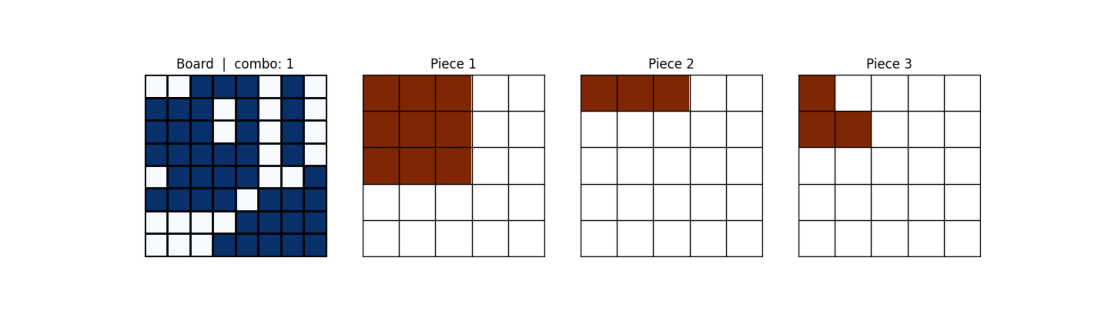


Game Terminated.

Final Reward: 11.1


In [4]:
STEPS = 30
total_reward = 0

for step_idx in range(STEPS):
    img = env.render()

    clear_output(wait=True)
    plt.figure(figsize=(14, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    print(f"--- Step {step_idx + 1} ---")
    print(f"Combo: {env.combo}  |  Pieces used: {env.pieces_used.tolist()}")
    print(f"Total reward so far: {total_reward:.1f}")

    # Collect valid actions: unused piece + valid placement
    valid_actions = []
    n_pos = env.grid_size * env.grid_size
    for piece_idx in range(env.n_pieces):
        if env.pieces_used[piece_idx]:
            continue
        for pos in range(n_pos):
            row = pos // env.grid_size
            col = pos % env.grid_size
            if env._can_place(env.pieces_grids[piece_idx], row, col):
                valid_actions.append(piece_idx * n_pos + pos)

    if not valid_actions:
        print("\nGame Over: No valid moves left.")
        break

    action = np.random.choice(valid_actions)
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

    time.sleep(0.5)

    if terminated or truncated:
        img = env.render()
        clear_output(wait=True)
        plt.figure(figsize=(14, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        print("\nGame Terminated.")
        break

print(f"\nFinal Reward: {total_reward:.1f}")
env.close()